In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox

In [5]:
clusters = [
    "urban_honolulu",
    "suburban_mililani",
    "rural_waianae",
    "remote_ocean_view"
]

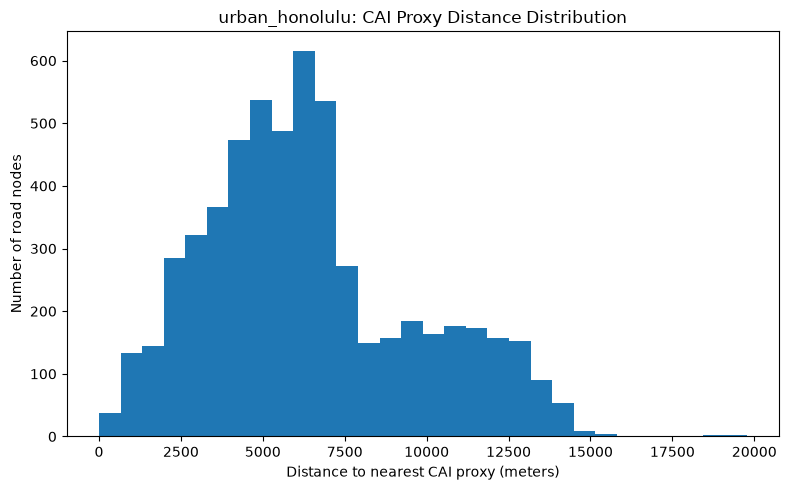

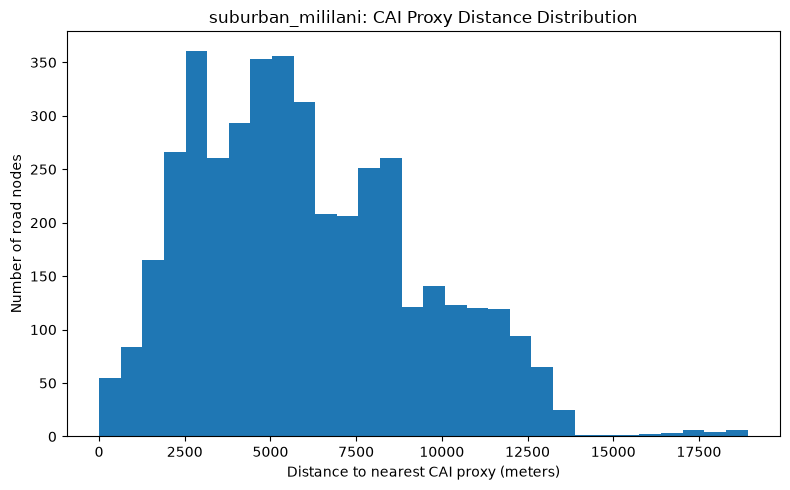

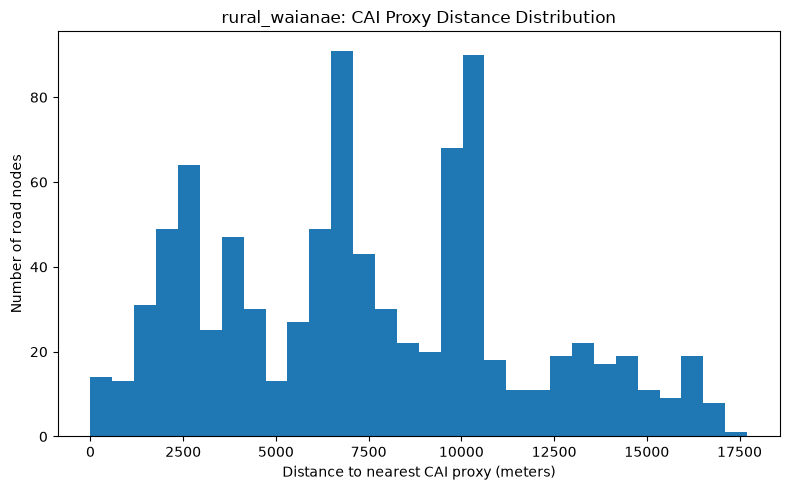

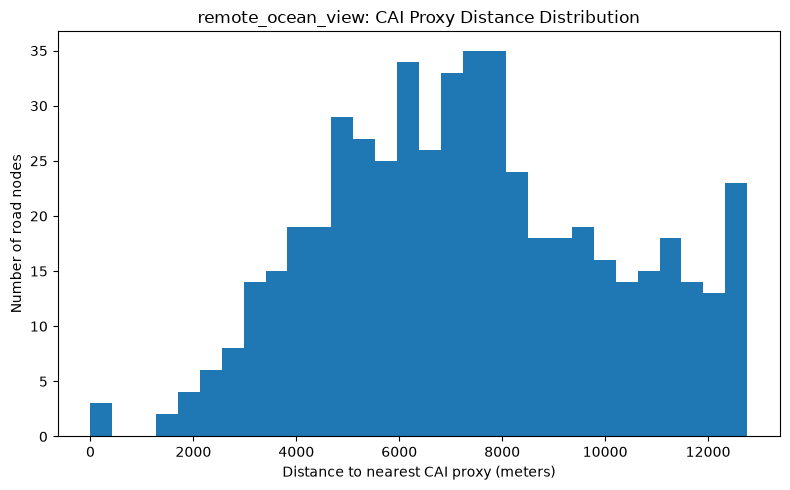

In [6]:
#histograms for CAI Proxy Distance Distribution
for name in clusters:
    G = ox.load_graphml(f"../data/raw/{name}_network_with_distance.graphml")
    nodes, edges = ox.graph_to_gdfs(G)
    
    vals = nodes["dist_to_cai_proxy"].astype(float)
    
    plt.figure(figsize=(8, 5))
    plt.hist(vals, bins=30)
    plt.xlabel("Distance to nearest CAI proxy (meters)")
    plt.ylabel("Number of road nodes")
    plt.title(f"{name}: CAI Proxy Distance Distribution")
    plt.tight_layout()
    plt.savefig(f"../results/plots/dist_to_cai_proxy/{name}_hist.png", bbox_inches="tight")
    plt.show()
    plt.close()

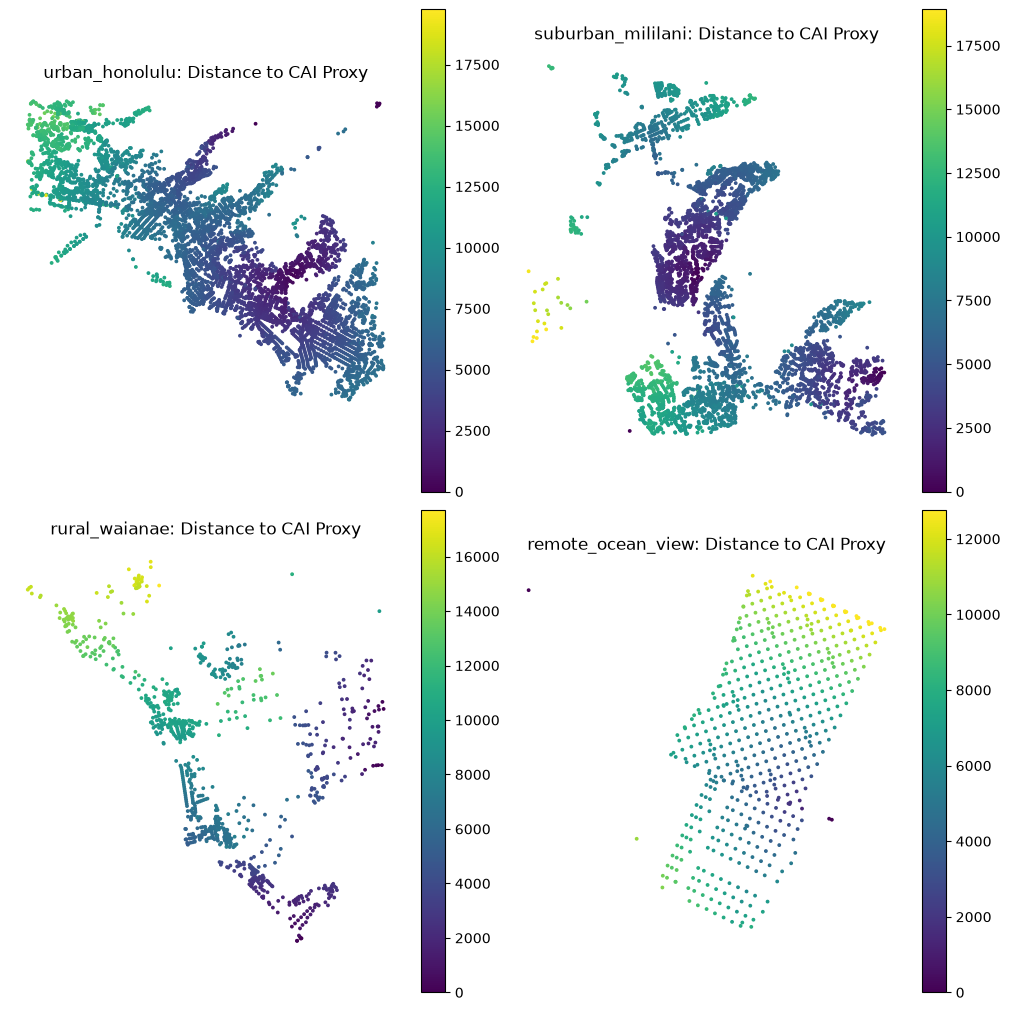

In [7]:
#spatial network plot for distance to CAI proxy
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)

for ax, name in zip(axes.flatten(), clusters):
    G = ox.load_graphml(f"../data/raw/{name}_network_with_distance.graphml")
    nodes, edges = ox.graph_to_gdfs(G)
    nodes["dist_to_cai_proxy"] = nodes["dist_to_cai_proxy"].astype(float)
    
    nodes.plot(ax=ax, column="dist_to_cai_proxy", legend=True, markersize=3)
    ax.set_title(f"{name}: Distance to CAI Proxy")
    ax.set_axis_off()

plt.savefig("../results/maps/dist_to_cai_proxy/all_clusters_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

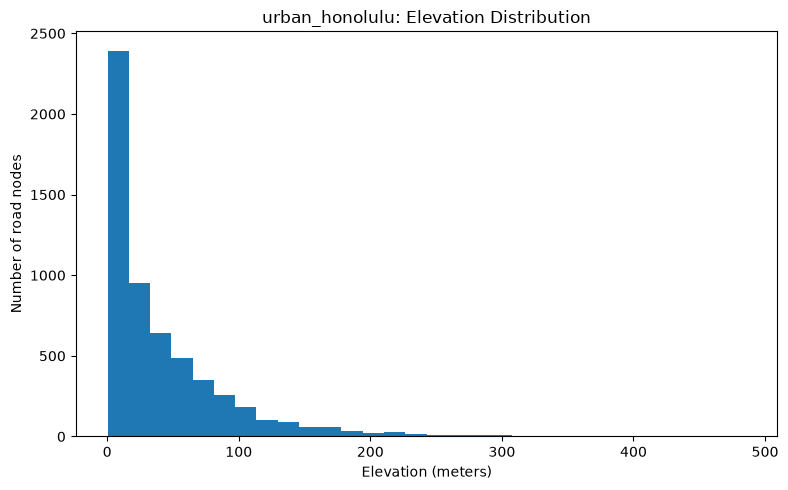

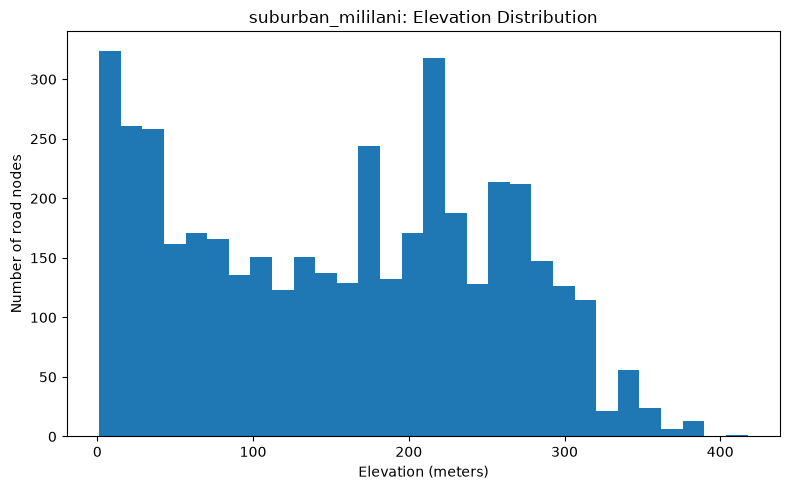

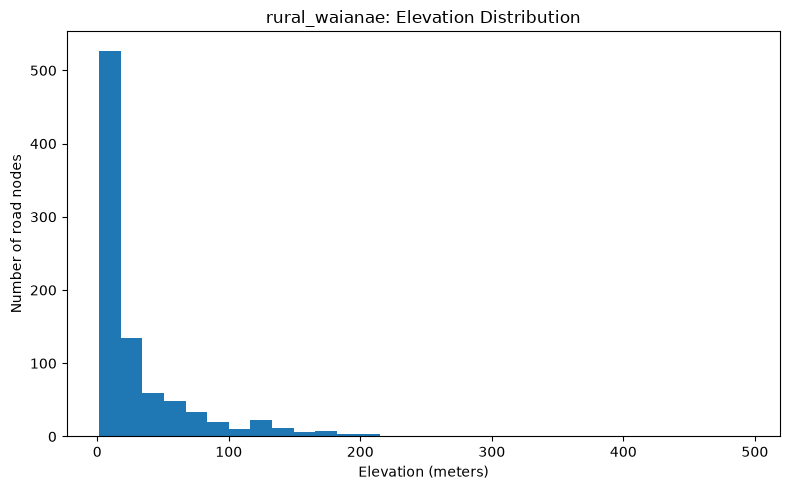

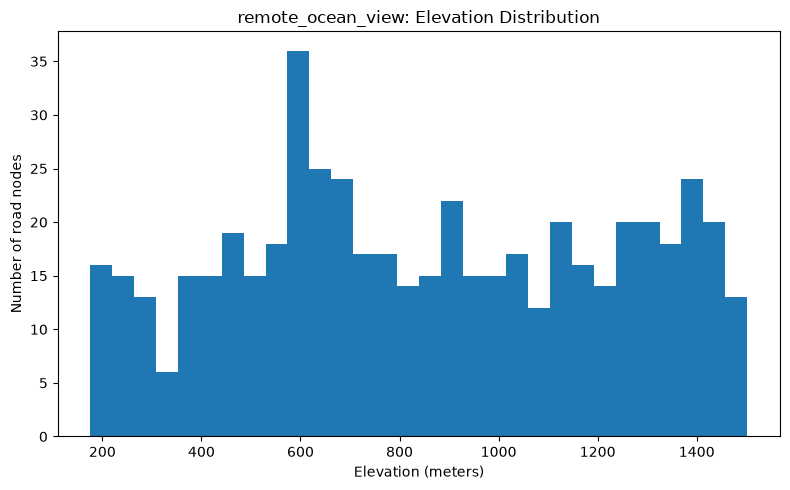

In [12]:
#histagram from elevation distribution
for name in clusters:
    G = ox.load_graphml(f"../data/raw/{name}_network_with_terrain.graphml")
    nodes, _ = ox.graph_to_gdfs(G)
    
    vals = nodes["elevation"].astype(float)
    
    plt.figure(figsize=(8, 5))
    plt.hist(vals, bins=30)
    plt.xlabel("Elevation (meters)")
    plt.ylabel("Number of road nodes")
    plt.title(f"{name}: Elevation Distribution")
    plt.tight_layout()
    plt.savefig(f"../results/plots/terrain/elevation distribution of {name}_hist.png", bbox_inches="tight")
    plt.show()
    plt.close()

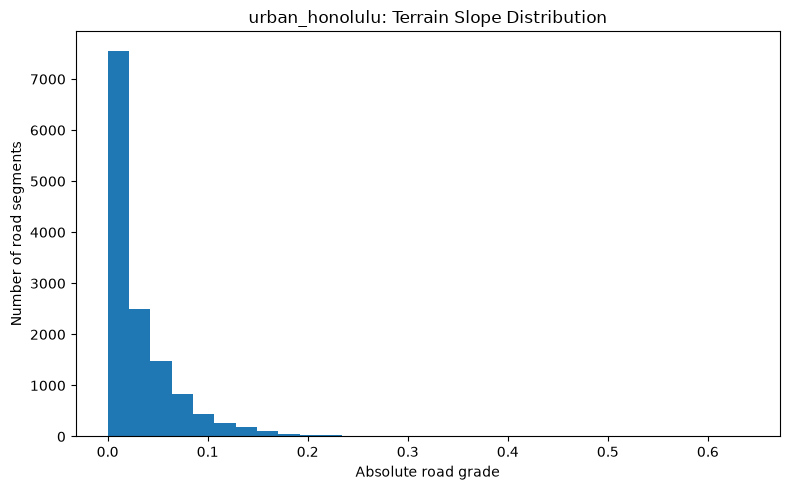

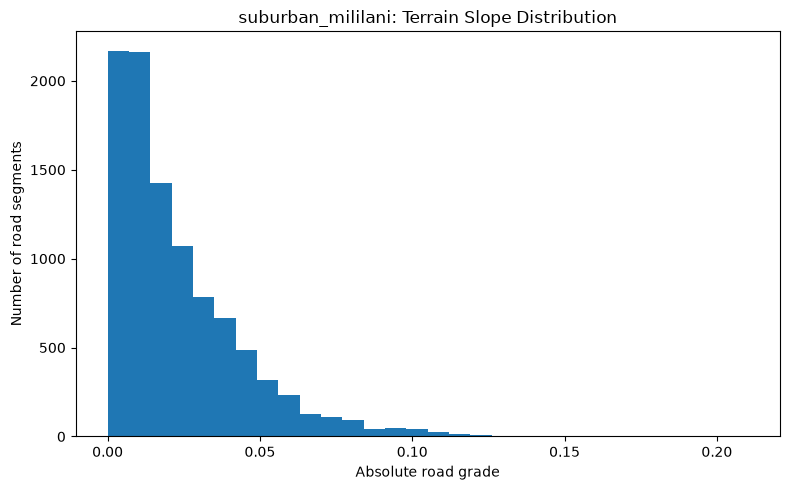

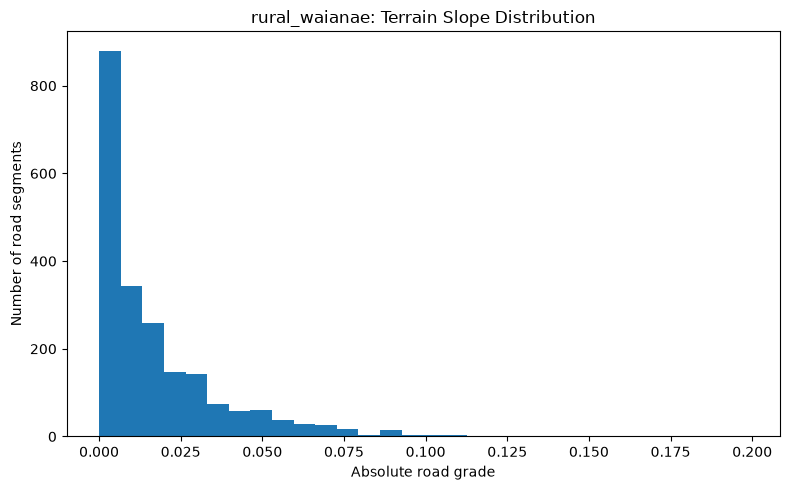

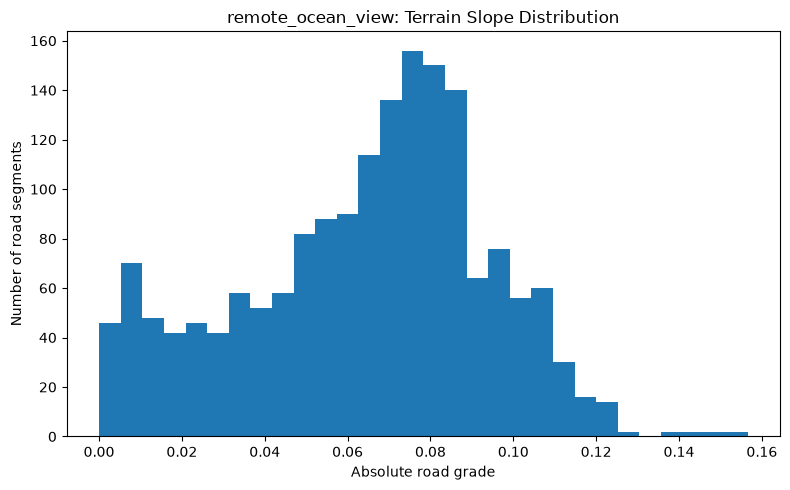

In [13]:
# histagram for slope 
for name in clusters:
    G = ox.load_graphml(f"../data/raw/{name}_network_with_terrain.graphml")
    _, edges = ox.graph_to_gdfs(G)
    
    vals = edges["grade_abs"].astype(float)
    
    plt.figure(figsize=(8, 5))
    plt.hist(vals, bins=30)
    plt.xlabel("Absolute road grade")
    plt.ylabel("Number of road segments")
    plt.title(f"{name}: Terrain Slope Distribution")
    plt.tight_layout()
    plt.savefig(f"../results/plots/terrain/slope distribution of {name}_hist.png", bbox_inches="tight")
    plt.show()
    plt.close()

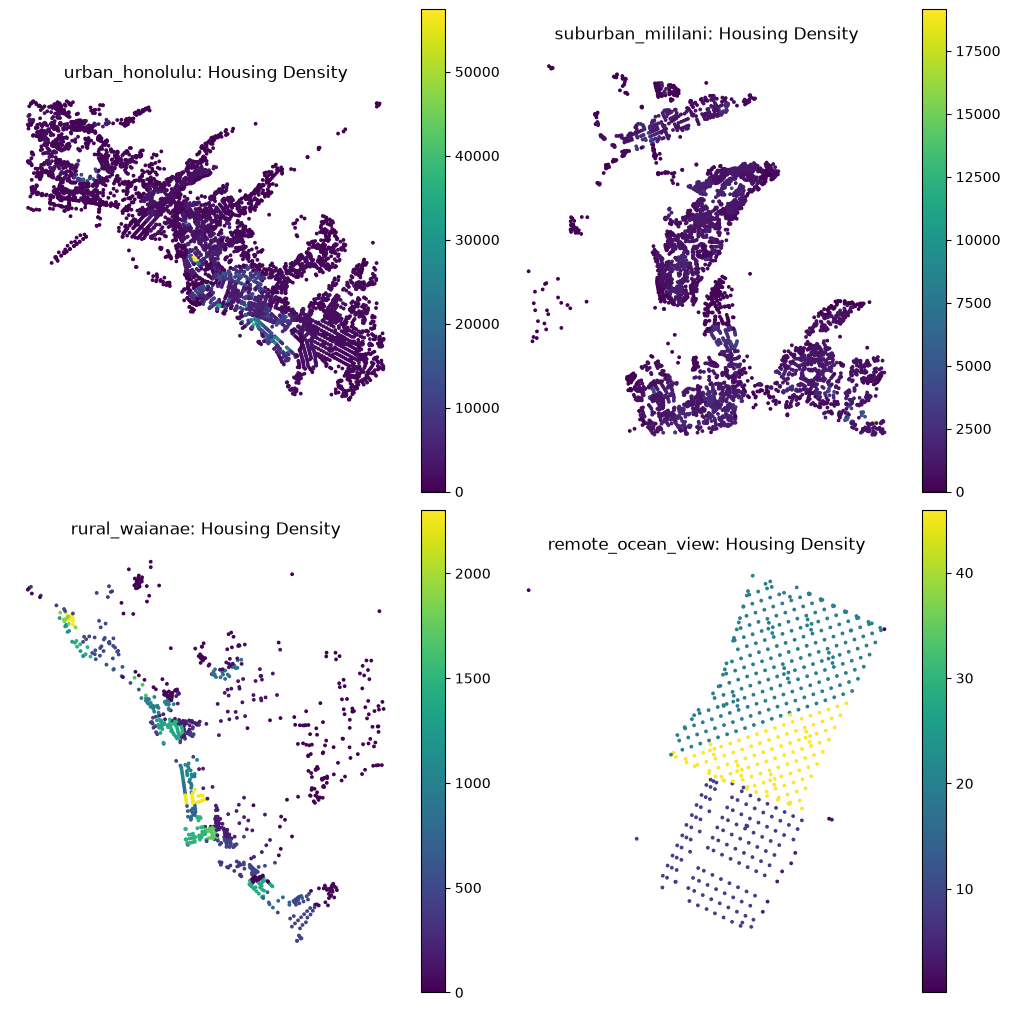

In [10]:
#spatial network plot for housing density
fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)

for ax, name in zip(axes.flatten(), clusters):
    nodes = gpd.read_file(f"../data/processed/{name}_nodes_with_features.gpkg")
    
    nodes.plot(
        ax=ax,
        column="housing_density",
        cmap="viridis",
        legend=True,
        markersize=3,
        missing_kwds={"color": "lightgrey"}
    )
    
    ax.set_title(f"{name}: Housing Density")
    ax.set_axis_off()

plt.savefig("../results/maps/housing_density/all_clusters_comparison.png", dpi=300, bbox_inches="tight")
plt.show()